### SML A1

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import struct
import pandas as pd

I have downloaded the Data directly from Kaggle [MNIST Dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset), hence no code block for the same.


##### Loading MNIST data

In [ ]:
def load_mnist(images_path, labels_path):
    # Load labels
    with open(labels_path, 'rb') as lb:
        # Read header: magic number and number of labels
        _, num = struct.unpack(">II", lb.read(8))
        # Read labels as unsigned bytes
        labels = np.fromfile(lb, dtype=np.uint8)

    # Load images
    with open(images_path, 'rb') as img:
        # Read header: magic number, count, rows, cols
        _, num, rows, cols = struct.unpack(">IIII", img.read(16))
        # Read images into numpy array
        images = np.fromfile(img, dtype=np.uint8).reshape(num, rows, cols)

    return images, labels


1. train-images-idx3-ubyte

All training images

IDX3 format,
Unsigned bytes (ubyte)

Shape: (60000, 28, 28)

Each image is 28×28 grayscale,
Pixel values range from 0 to 255

2. train-labels-idx1-ubyte

Labels for training images

IDX1 format,
Unsigned bytes (ubyte)

Shape: (60000,)

Each value is a digit label from 0 to 9,
Label at index i corresponds to image i in the training image file

3. t10k-images-idx3-ubyte

All test images (10k = 10,000)

IDX3 format,
Unsigned bytes (ubyte)

Shape: (10000, 28, 28)

Same structure as training images,
Used for evaluation

4. t10k-labels-idx1-ubyte

Labels for test images

IDX1 format,
Unsigned bytes (ubyte)

Shape: (10000,)

Ground truth labels for test images

In [3]:
X_train_all, y_train_all = load_mnist(
    "Data/train-images.idx3-ubyte",
    "Data/train-labels.idx1-ubyte"
)
X_test_all, y_test_all = load_mnist(
    "Data/t10k-images.idx3-ubyte",
    "Data/t10k-labels.idx1-ubyte"
)

In [4]:
print("X_train_all:", X_train_all.shape)
print("y_train_all:", y_train_all.shape)
print()
print("X_test_all:", X_test_all.shape)
print("y_test_all:", y_test_all.shape)

X_train_all: (60000, 28, 28)
y_train_all: (60000,)

X_test_all: (10000, 28, 28)
y_test_all: (10000,)


Filter digits 0,1,2 

then

Sample 100 per Class (randomly)

In [ ]:
classes=[0,1,2]
samples_per_class=100

np.random.seed(42)
def sample_data(X,y):
    X_out, y_out = [], []
    for c in classes:
        idx_all = np.where(y == c)[0]
        idx = np.random.choice(idx_all, samples_per_class, replace=False)
        X_out.append(X[idx])
        y_out.append(y[idx])
    return np.vstack(X_out), np.hstack(y_out)

X_train, y_train = sample_data(X_train_all, y_train_all)
X_test, y_test = sample_data(X_test_all, y_test_all)

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print()
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (300, 28, 28)
y_train: (300,)

X_test: (300, 28, 28)
y_test: (300,)


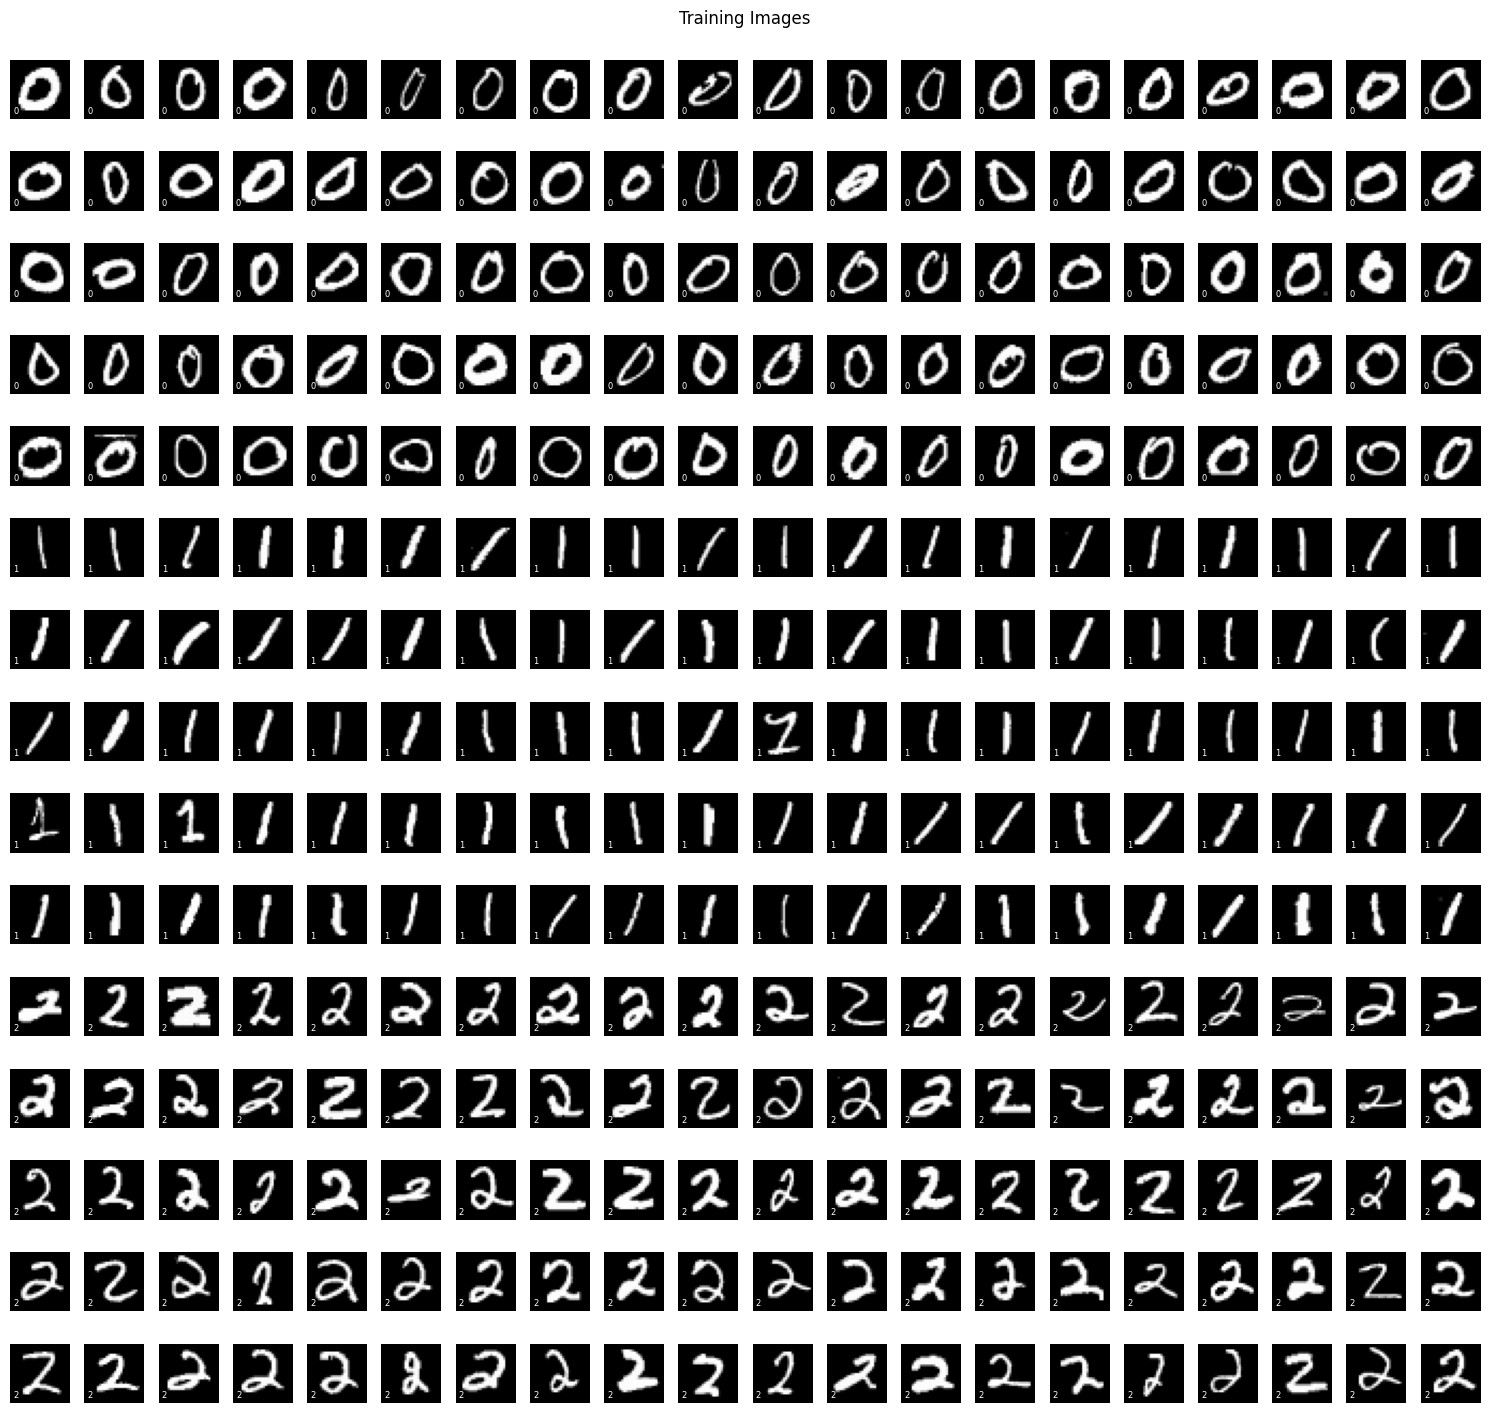

In [7]:
plt.figure(figsize=(15, 15))

for i in range(X_train.shape[0]):
    plt.subplot(15, 20, i + 1)
    plt.imshow(X_train[i], cmap="gray")

    # annotation: show label
    plt.text(
        1, 26, str(y_train[i]),
        color="white",
        fontsize=6,
        ha="left",
        va="bottom"
    )

    plt.axis("off")

plt.suptitle("Training Images", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


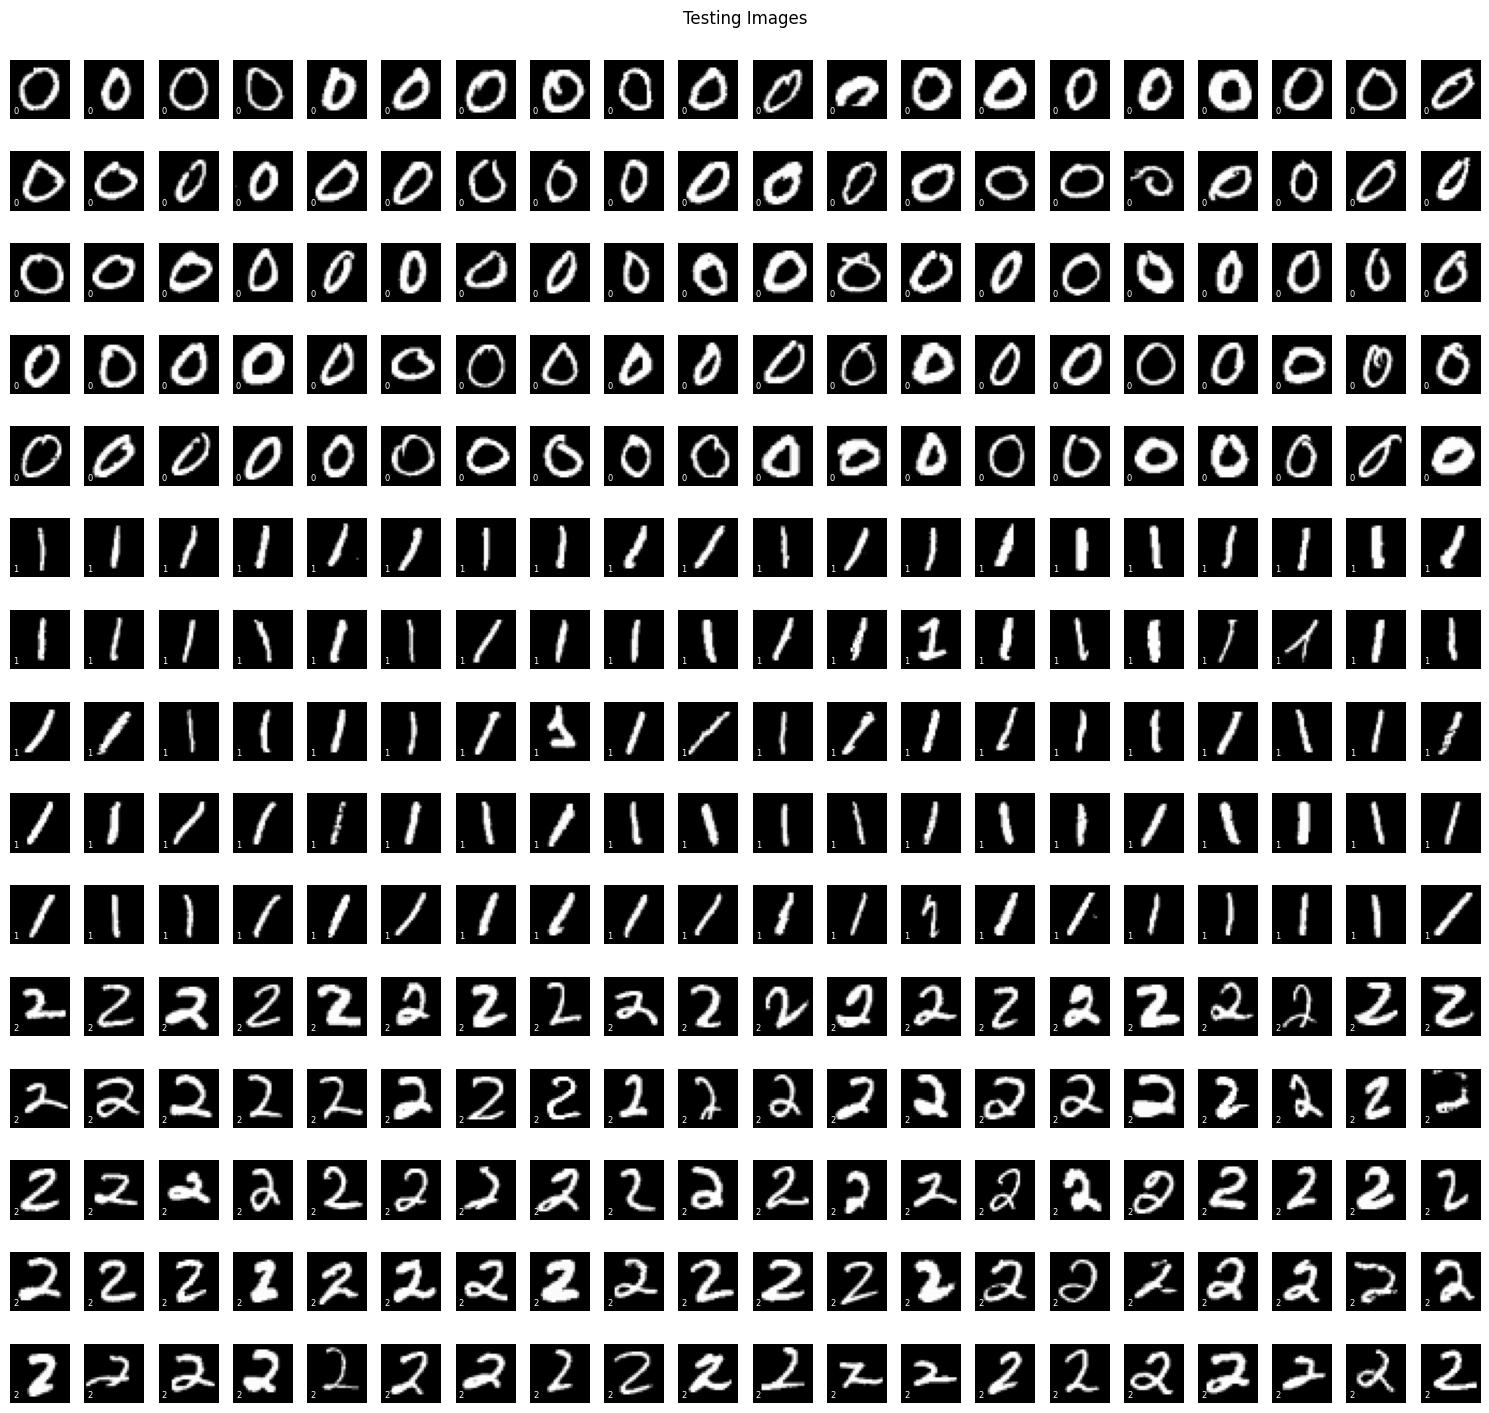

In [ ]:
plt.figure(figsize=(15, 15))

for i in range(X_test.shape[0]):
    plt.subplot(15, 20, i + 1)
    plt.imshow(X_test[i], cmap="gray")

    plt.text(
        1, 26, str(y_test[i]),
        color="white",
        fontsize=6,
        ha="left",
        va="bottom"
    )

    plt.axis("off")

plt.suptitle("Testing Images", y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Stacking the images

In [9]:
# Stack images from (N, 28, 28) to (N, 784)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)


Normalizing the data 

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

##### Computing Maximum Likelihood Estimate Mean and Covariance

In [ ]:
def mle_mean_cov(X):
    mu = np.mean(X, axis=0)
    centered = X - mu
    cov = (centered.T @ centered) / X.shape[0]  
    return mu, cov

Estimating parameters for each class

In [12]:
classes = [0,1,2]
means = {}
covs = {}

for c in classes:
    X_c = X_train[y_train == c]
    mu, cov = mle_mean_cov(X_c)
    means[c] = mu
    covs[c] = cov


##### Discriminant Functions

LDA (shared covariance)

In [13]:
shared_cov = sum(covs.values()) / len(covs)

eps = 1e-3
shared_cov_reg = shared_cov + eps * np.eye(shared_cov.shape[0])
shared_cov_inv = np.linalg.inv(shared_cov_reg)

def lda_predict(X):
    scores = []
    for c in classes:
        mu = means[c]
        score = X @ shared_cov_inv @ mu - 0.5 * mu @ shared_cov_inv @ mu
        scores.append(score)
    return np.argmax(np.vstack(scores), axis=0)


QDA (class specific covariance)

In [14]:
eps = 1e-3   

def qda_predict(X):
    scores = []

    for c in classes:
        mu = means[c]
        cov = covs[c]

        cov_reg = cov + eps * np.eye(cov.shape[0])
        cov_inv = np.linalg.inv(cov_reg)
        # log_det = np.log(np.linalg.det(cov_reg))
        sign, log_det = np.linalg.slogdet(cov_reg)

        diff = X - mu
        g = -0.5 * np.sum(diff @ cov_inv * diff, axis=1) - 0.5 * log_det
        scores.append(g)

    return np.argmax(np.vstack(scores), axis=0)


##### Accuracy calc

In [ ]:
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [16]:
y_pred_lda = lda_predict(X_test)
y_pred_qda = qda_predict(X_test)

lda_acc = compute_accuracy(y_test, y_pred_lda)
qda_acc = compute_accuracy(y_test, y_pred_qda)

print(f"LDA accuracy: {lda_acc:.4f}")
print(f"QDA accuracy: {qda_acc:.4f}")

LDA accuracy: 0.9033
QDA accuracy: 0.9900


Although accuracy is sufficient due to class balance, Precision, Recall and F1-score are additionally reported for completeness.

In [17]:
def precision_recall_f1(y_true, y_pred, cls):
    tp = np.sum((y_pred == cls) & (y_true == cls))
    fp = np.sum((y_pred == cls) & (y_true != cls))
    fn = np.sum((y_pred != cls) & (y_true == cls))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

In [18]:
rows = []

for model, y_pred in [("LDA", y_pred_lda), ("QDA", y_pred_qda)]:
    for c in classes:
        p, r, f1 = precision_recall_f1(y_test, y_pred, c)
        rows.append({
            "Model": model,
            "Class": c,
            "Precision": round(p, 3),
            "Recall": round(r, 3),
            "F1-score": round(f1, 3)
        })

df_metrics = pd.DataFrame(rows)

print(df_metrics.to_string(index=False))

Model  Class  Precision  Recall  F1-score
  LDA      0      0.922    0.94     0.931
  LDA      1      0.866    0.97     0.915
  LDA      2      0.930    0.80     0.860
  QDA      0      0.990    1.00     0.995
  QDA      1      0.990    0.99     0.990
  QDA      2      0.990    0.98     0.985


Discriminant Value for One Test Sample

In [19]:
x_sample = X_test[0]

print("LDA discriminant values for one test sample:")

for c in classes:
    mu = means[c]
    g = x_sample @ shared_cov_inv @ mu - 0.5 * mu @ shared_cov_inv @ mu
    print(f"  Class {c}: {g:.4f}")


LDA discriminant values for one test sample:
  Class 0: 73.7337
  Class 1: -74.1704
  Class 2: -8.3147


In [20]:
x_sample = X_test[0]
eps = 1e-3

print("QDA discriminant values for one test sample:")

for c in classes:
    mu = means[c]
    cov = covs[c]

    cov_reg = cov + eps * np.eye(cov.shape[0])
    cov_inv = np.linalg.inv(cov_reg)

    g = -0.5 * (x_sample - mu).T @ cov_inv @ (x_sample - mu)
    print(f"  Class {c}: {g:.4f}")


QDA discriminant values for one test sample:
  Class 0: -3689.4010
  Class 1: -32419.6758
  Class 2: -8443.8655


##### t-SNE Plots (sk-learn)

Train Data

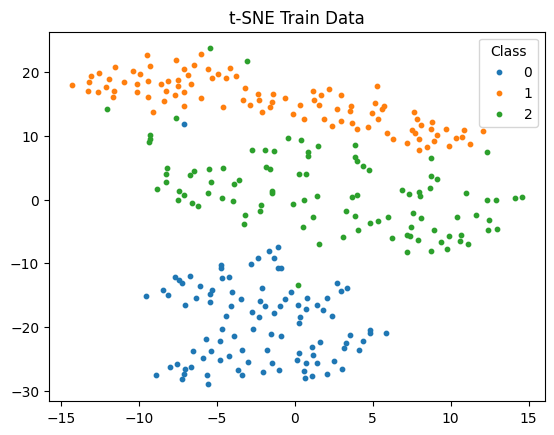

In [21]:
np.random.seed(42)
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_train)

plt.figure()
for c in classes:
    idx = y_train == c
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1], s=10, label=str(c))

plt.legend(title="Class")
plt.title("t-SNE Train Data")
plt.show()


Test Data

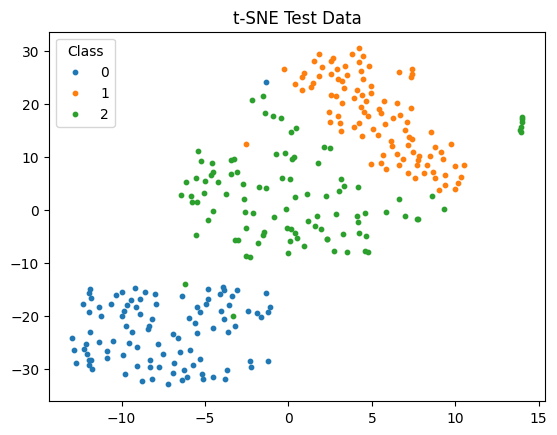

In [ ]:
np.random.seed(42)
tsne = TSNE(n_components=2, random_state=42)
X_embedded_test = tsne.fit_transform(X_test)

plt.figure()
for c in classes:
    idx = y_test == c
    plt.scatter(X_embedded_test[idx, 0],X_embedded_test[idx, 1],s=10,label=str(c))

plt.legend(title="Class")
plt.title("t-SNE Test Data")
plt.show()


 Umang Aggarwal (2023567)